# Swin Transformer -- Figshare 4-Class (224x224, 35 epochs, 100% fine-tuning, NO early stopping)
Same data pipeline as the EfficientNetB4 run: all Figshare images pooled from its `training images` / `validation images` / `test images` folders, shuffled, and re-split stratified **60% train / 20% validation / 20% test** (`random_state=42`). 4 classes: adenocarcinoma, squamous_cell_carcinoma, large_cell_carcinoma, normal.

**Specifications for this run (same as EfficientNetB4, except no early stopping):**
- Image size: **224x224** (this happens to be Swin-Base's native resolution -- `swin-base-patch4-window7-224` was pretrained at exactly this size)
- Batch size: **16**
- Epochs: **35, always runs the full 35 -- no early stopping**
- Optimizer: **Adam, learning_rate=5e-4**
- **100% fine-tuning** -- the entire Swin backbone is trainable from epoch 1
- **No data augmentation** and **no class weighting**

**Implementation note:** Keras doesn't ship Swin Transformer natively, so this uses Hugging Face `transformers`' `TFSwinForImageClassification` (`microsoft/swin-base-patch4-window7-224`), wrapped in a small subclassed Keras model to handle the channel layout (HF Swin expects channels-first `(N,C,H,W)` internally; our data pipeline produces channels-last `(N,H,W,C)`, so the wrapper transposes before calling the backbone). **This notebook needs internet access enabled in the Kaggle notebook** to download the pretrained Swin weights from Hugging Face Hub (same requirement the Figshare download cell already has).

## 0. Explore /kaggle/input

In [6]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []


## 1. Install + Imports
Pinned to `transformers==4.46.3` specifically -- Hugging Face deprecated and then fully removed TensorFlow support from `transformers` (merged ~May 2025), so any recent/latest install no longer has `TFSwinForImageClassification` at all (`pip install -U transformers` will break with an ImportError). 4.46.3 is a pre-deprecation release confirmed to still include the TF Swin classes.

**Also installs `tf-keras`** -- current TensorFlow defaults to Keras 3, but `transformers`' TF models (including `TFSwinForImageClassification`) were built against legacy Keras 2 and silently fail to build their weights under Keras 3 (symptom: `model.weights` comes back empty, `trainable_fraction` divides by zero in the FLOPs cell). Setting `TF_USE_LEGACY_KERAS=1` **before** `tensorflow` is imported tells TensorFlow to use the legacy `tf_keras` package instead of its bundled Keras 3.

**If you already ran this notebook once and hit the FLOPs `ZeroDivisionError` or a Swin-related build issue: restart the kernel before re-running from cell 1.** The env var only takes effect if it's set before TensorFlow is imported for the first time in the session -- it won't retroactively fix an already-running kernel.

In [7]:
!pip install -q "transformers==4.46.3" tf-keras

In [8]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # must be set BEFORE tensorflow is imported

import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from transformers import TFSwinForImageClassification

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("Keras version in use:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "unknown")

TARGET_CLASSES = ["adenocarcinoma", "squamous_cell_carcinoma", "large_cell_carcinoma", "normal"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4
SWIN_CHECKPOINT = "microsoft/swin-base-patch4-window7-224"

Keras version in use: unknown


## 2. Figshare -- Download

In [9]:
FIGSHARE_DOWNLOAD_URL = "https://ndownloader.figshare.com/files/52627007"
FIGSHARE_ZIP = "/kaggle/working/lung_cancer_dataset.zip"
FIGSHARE_DIR = "/kaggle/working/lung_cancer_dataset"
EXPECTED_SIZE = 138394807

if os.path.exists(FIGSHARE_ZIP) and os.path.getsize(FIGSHARE_ZIP) != EXPECTED_SIZE:
    os.remove(FIGSHARE_ZIP)

if not os.path.exists(FIGSHARE_ZIP):
    print("Downloading Figshare dataset...")
    resp = requests.get(FIGSHARE_DOWNLOAD_URL, stream=True, timeout=120, headers={"User-Agent": "Mozilla/5.0"})
    with open(FIGSHARE_ZIP, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    size = os.path.getsize(FIGSHARE_ZIP)
    print("Downloaded size:", size, " Matches expected:", size == EXPECTED_SIZE)

if not os.path.exists(FIGSHARE_DIR):
    print("Extracting...")
    with zipfile.ZipFile(FIGSHARE_ZIP, 'r') as z:
        z.extractall(FIGSHARE_DIR)
    print("Done.")

## 3. Pool ALL images, then stratified 60/20/20 split

In [10]:
FIGSHARE_LABEL_MAP = {
    "adenocarcinoma": "adenocarcinoma",
    "squamous.cell.carcinoma": "squamous_cell_carcinoma",
    "large.cell.carcinoma": "large_cell_carcinoma",
    "normal": "normal",
}

def build_figshare_df_from_folder(folder_name):
    split_dir = None
    for dirpath, dirnames, filenames in os.walk(FIGSHARE_DIR):
        if folder_name in dirnames:
            split_dir = os.path.join(dirpath, folder_name)
            break
    if split_dir is None:
        print(f"!! Could not find '{folder_name}'")
        return pd.DataFrame()
    records = []
    for folder in os.listdir(split_dir):
        folder_path = os.path.join(split_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        raw_prefix = folder.split('_')[0]
        label = FIGSHARE_LABEL_MAP.get(raw_prefix)
        if label is None:
            continue
        for fname in os.listdir(folder_path):
            records.append({"filepath": os.path.join(folder_path, fname), "label": label})
    return pd.DataFrame(records)

_train_part = build_figshare_df_from_folder("training images")
_val_part   = build_figshare_df_from_folder("validation images")
_test_part  = build_figshare_df_from_folder("test images")

full_pool = pd.concat([_train_part, _val_part, _test_part], ignore_index=True)
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 600  Val size: 200  Test size: 200

Train class balance:
 label
adenocarcinoma             203
squamous_cell_carcinoma    156
normal                     129
large_cell_carcinoma       112
Name: count, dtype: int64

Val class balance:
 label
adenocarcinoma             67
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       38
Name: count, dtype: int64

Test class balance:
 label
adenocarcinoma             68
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       37
Name: count, dtype: int64


## 4. Data generators -- no augmentation, ImageNet mean/std normalization for Swin
Swin (like most Hugging Face vision transformers) was pretrained with ImageNet mean/std normalization, not EfficientNet's own preprocessing scheme -- so a custom `preprocessing_function` is used instead of `efficientnet.preprocess_input`.

In [11]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def swin_preprocess(img):
    img = img / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img

datagen = ImageDataGenerator(preprocessing_function=swin_preprocess)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_gen = datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
print("class_indices:", train_gen.class_indices)

Found 600 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
class_indices: {'adenocarcinoma': 0, 'squamous_cell_carcinoma': 1, 'large_cell_carcinoma': 2, 'normal': 3}


## 5. Model -- Swin Transformer (Base, 224), 100% trainable from the start
`TFSwinForImageClassification.from_pretrained(..., num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)` loads ImageNet-pretrained Swin-Base weights and replaces its classification head with a fresh `NUM_CLASSES`-way head. `ignore_mismatched_sizes=True` is required because the original head was for 1000 ImageNet classes.

The wrapper `SwinClassifier` transposes input from channels-last (what our data pipeline produces) to channels-first (what `TFSwinForImageClassification` expects internally), and returns raw logits -- so the loss below uses `from_logits=True` rather than a softmax layer.

In [12]:
class SwinClassifier(tf.keras.Model):
    def __init__(self, num_classes, checkpoint=SWIN_CHECKPOINT):
        super().__init__()
        self.backbone = TFSwinForImageClassification.from_pretrained(
            checkpoint, num_labels=num_classes, ignore_mismatched_sizes=True
        )
        self.backbone.trainable = True  # 100% fine-tuning -- entire backbone trainable from epoch 1

    def call(self, inputs, training=False):
        x = tf.transpose(inputs, perm=[0, 3, 1, 2])  # NHWC -> NCHW (HF Swin expects channels-first)
        outputs = self.backbone(pixel_values=x, training=training)
        return outputs.logits

model = SwinClassifier(num_classes=NUM_CLASSES)
_ = model(tf.zeros((1, 224, 224, 3), dtype=tf.float32))  # dummy forward pass -- forces all sub-layer weights to actually build
model.summary()

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

I0000 00:00:1789931093.188555      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789931093.192056      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFSwinForImageClassification: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFSwinForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSwinForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFSwinForImageClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinForImageClassification for predictions without further training.
Some weights of TFSwinForImageClassification were not initialized from the model checkpoint are newly init

Model: "swin_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tf_swin_for_image_classifi  multiple                  86804948  
 cation (TFSwinForImageClas                                      
 sification)                                                     
                                                                 
Total params: 86804948 (331.13 MB)
Trainable params: 86747324 (330.91 MB)
Non-trainable params: 57624 (225.09 KB)
_________________________________________________________________


## 6. FLOPs -- cost of fine-tuning (image-wise and batch-wise)
Same methodology as the EfficientNetB4 notebooks: forward-pass FLOPs measured directly via TensorFlow's graph profiler, and training FLOPs derived as `(1 + 2 * trainable_fraction)x forward`, where `trainable_fraction` is read from `model.trainable_weights` vs `model.weights` -- not assumed. Since `self.backbone.trainable = True` above, this comes out to `trainable_fraction=1.0` and a `3x` multiplier here too, exactly as with EfficientNetB4's 100% fine-tuning.

In [13]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, input_shape, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler.
    `input_shape` is passed explicitly (e.g. (224, 224, 3)) since a subclassed model
    doesn't always expose `.input` the way a functional-API model does."""
    full_shape = [batch_size] + list(input_shape)
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(full_shape, tf.float32)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

# --- Trainable-vs-frozen split, read directly off the model ---
trainable_param_count = sum(int(tf.size(w)) for w in model.trainable_weights)
total_param_count = sum(int(tf.size(w)) for w in model.weights)
trainable_fraction = trainable_param_count / total_param_count

BACKWARD_MULTIPLIER = 2 * trainable_fraction
TOTAL_MULTIPLIER = 1 + BACKWARD_MULTIPLIER

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,}  (trainable_fraction={trainable_fraction:.4f})")
print(f"Derived training FLOPs multiplier: {TOTAL_MULTIPLIER:.4f}x forward\n")

# --- FORWARD pass FLOPs ---
flops_per_image_fwd = get_flops(model, input_shape=(224, 224, 3), batch_size=1)
flops_per_batch_fwd = get_flops(model, input_shape=(224, 224, 3), batch_size=BATCH_SIZE)

# --- BACKWARD pass FLOPs (derived, not separately traced) ---
flops_per_image_bwd = flops_per_image_fwd * BACKWARD_MULTIPLIER
flops_per_batch_bwd = flops_per_batch_fwd * BACKWARD_MULTIPLIER

# --- TOTAL training FLOPs (forward + backward) ---
flops_per_image_total = flops_per_image_fwd * TOTAL_MULTIPLIER
flops_per_batch_total = flops_per_batch_fwd * TOTAL_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_total = flops_per_batch_total * steps_per_epoch
flops_full_run_total = flops_per_epoch_total * EPOCHS  # exact -- no early stopping, always runs all EPOCHS

print("=== FORWARD ===")
print(f"Per image:  {flops_per_image_fwd:,}  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,}  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== BACKWARD ===")
print(f"Per image:  {flops_per_image_bwd:,.0f}  (~{flops_per_image_bwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_bwd:,.0f}  (~{flops_per_batch_bwd/1e9:.3f} GFLOPs)")

print("\n=== TOTAL (forward + backward) ===")
print(f"Per image:  {flops_per_image_total:,.0f}  (~{flops_per_image_total/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_total:,.0f}  (~{flops_per_batch_total/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_total:,.0f}  (~{flops_per_epoch_total/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (exact -- no early stopping):  {flops_full_run_total:,.0f}  (~{flops_full_run_total/1e15:.3f} PFLOPs)")

Trainable params: 86,747,324 / 86,804,948  (trainable_fraction=0.9993)
Derived training FLOPs multiplier: 2.9987x forward



I0000 00:00:1789931125.882367      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789931125.882625      58 single_machine.cc:376] Starting new session
I0000 00:00:1789931125.897496      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789931125.899136      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

I0000 00:00:1789931180.285535      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789931180.285769      58 single_machine.cc:376] Starting new session
I0000 00:00:1789931180.300767      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789931180.302479      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

## 7. Callbacks -- NO early stopping
Only `ModelCheckpoint` (saved as weights, since HF subclassed models don't reliably serialize with Keras's full-model `.keras` format). Every run trains the complete 35 epochs, unlike the EfficientNetB4 notebooks.

In [14]:
callbacks = [
    ModelCheckpoint(
        "best_swin_figshare_224.weights.h5",
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
]

## 8. Fine-tune (100% -- entire backbone trainable, full 35 epochs, no early stopping)

In [15]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/35


I0000 00:00:1789931312.267687     144 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


38/38 [==============================] - ETA: 0s - loss: 1.5461 - accuracy: 0.2833
Epoch 1: val_accuracy improved from -inf to 0.35500, saving model to best_swin_figshare_224.weights.h5
38/38 [==============================] - 195s 2s/step - loss: 1.5461 - accuracy: 0.2833 - val_loss: 1.3413 - val_accuracy: 0.3550
Epoch 2/35


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


38/38 [==============================] - ETA: 0s - loss: 1.2269 - accuracy: 0.4217
Epoch 2: val_accuracy improved from 0.35500 to 0.46500, saving model to best_swin_figshare_224.weights.h5
38/38 [==============================] - 38s 992ms/step - loss: 1.2269 - accuracy: 0.4217 - val_loss: 0.9759 - val_accuracy: 0.4650
Epoch 3/35
38/38 [==============================] - ETA: 0s - loss: 1.0329 - accuracy: 0.4817
Epoch 3: val_accuracy did not improve from 0.46500
38/38 [==============================] - 36s 959ms/step - loss: 1.0329 - accuracy: 0.4817 - val_loss: 1.0078 - val_accuracy: 0.4050
Epoch 4/35
38/38 [==============================] - ETA: 0s - loss: 1.0386 - accuracy: 0.4917
Epoch 4: val_accuracy did not improve from 0.46500
38/38 [==============================] - 35s 929ms/step - loss: 1.0386 - accuracy: 0.4917 - val_loss: 1.0404 - val_accuracy: 0.4000
Epoch 5/35
38/38 [==============================] - ETA: 0s - loss: 1.0128 - accuracy: 0.5167
Epoch 5: val_accuracy did not i

## 9. Plot train/val loss + accuracy

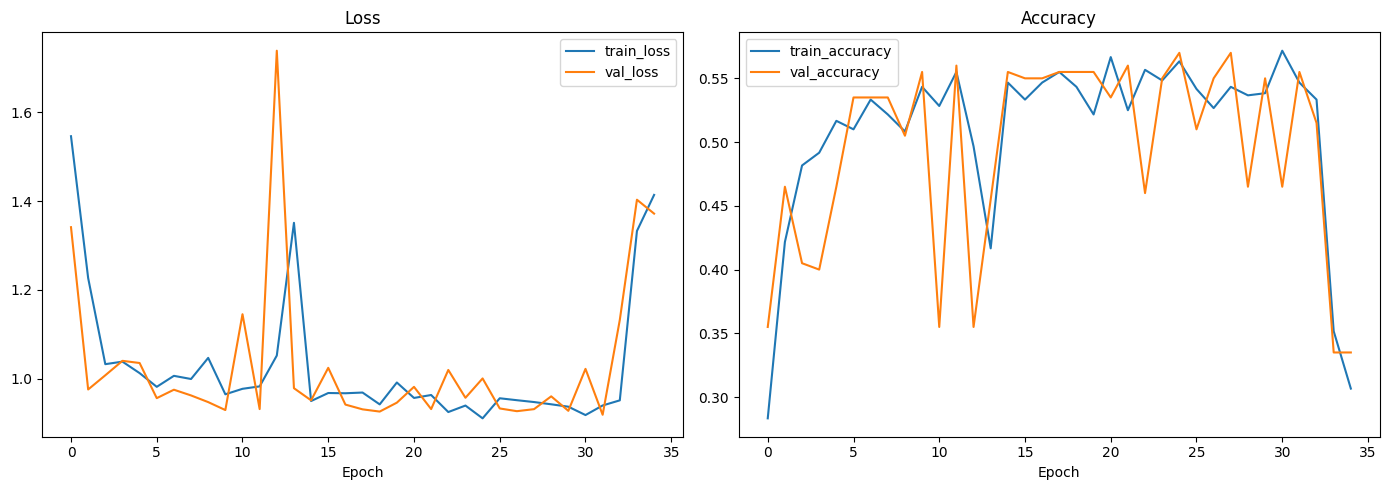

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_swin_figshare_224.png", dpi=150)
plt.show()

## 10. Final evaluation on TEST set

13/13 [==============================] - 4s 296ms/step - loss: 0.9635 - accuracy: 0.5750
Test loss: 0.9635  Test accuracy: 0.5750

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma     0.4769    0.9118    0.6263        68
squamous_cell_carcinoma     0.5263    0.1923    0.2817        52
   large_cell_carcinoma     0.0000    0.0000    0.0000        37
                 normal     0.8431    1.0000    0.9149        43

               accuracy                         0.5750       200
              macro avg     0.4616    0.5260    0.4557       200
           weighted avg     0.4803    0.5750    0.4829       200

Test macro F1: 0.4557

Prediction distribution:
adenocarcinoma             130
normal                      51
squamous_cell_carcinoma     19
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


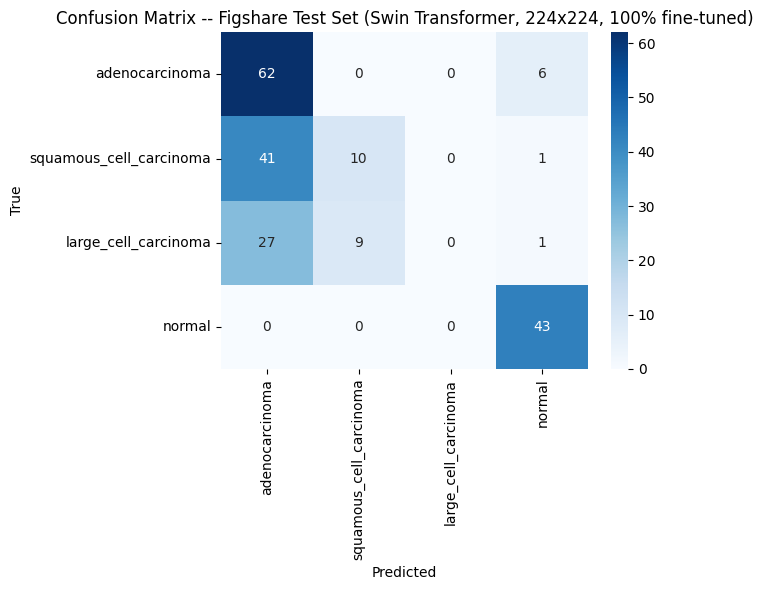


Swin Transformer (Figshare, 224x224) test accuracy: 57.50%


In [17]:
model.load_weights("best_swin_figshare_224.weights.h5")

test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

test_gen.reset()
y_pred_logits = model.predict(test_gen, verbose=0)
y_pred_idx = np.argmax(y_pred_logits, axis=1)
y_true_idx = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- Figshare Test Set (Swin Transformer, 224x224, 100% fine-tuned)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_swin_figshare_224.png", dpi=150)
plt.show()

print(f"\nSwin Transformer (Figshare, 224x224) test accuracy: {test_acc*100:.2f}%")